# Causal AI Fairness — Example 3

In this notebook, we reproduce **Example 3** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects, together with expectations
- inspect the distributions of the effects
- Report from the LLM given the results

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [1]:
from pathlib import Path
import sys
import json
import os
import pandas as pd
from pgmpy.estimators import BayesianEstimator
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(override=True)  # loads OPENAI_API_KEY from .env

if os.getenv("OPENAI_API_KEY") is None:
    raise RuntimeError("OPENAI_API_KEY not found. ")

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.visualisation.graph import visualize_sfm
from src.llm import (
    prepare_llm_payload_general,
    payload_to_json,
    summarize_with_llm_combined,
)

REPO_ROOT

/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [2]:
data_path = REPO_ROOT / "data" / "processed" / "student_mat.csv"
df = pd.read_csv(data_path)

selected_columns = [
    "S2_sex",
    "address",
    "failures",
]

df[selected_columns].head()


,S2_sex,address,failures
0,F,U,0
1,F,U,0
2,F,U,3
3,F,U,0
4,F,U,0


In [3]:
df["S2_sex"].dtype
df["S2_sex"] = df["S2_sex"].astype("category")
df["failures"].dtype
df["address"].dtype
df["address"] = df["address"].astype("category")


In [4]:
df[selected_columns].nunique().rename("cardinality")

S2_sex      2
address     2
failures    4
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [5]:
private_attr = "S2_sex"
outcome_attr = "failures"
confounders = []
mediators = ["address"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_sex', 'address'), ('S2_sex', 'failures'), ('address', 'failures')]

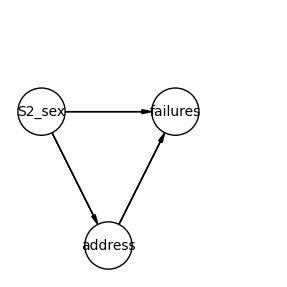

In [6]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [7]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()


2026-04-27 17:55:17.665 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_sex': 'C', 'address': 'C', 'failures': 'N'}


In [8]:
variable_metadata = pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)
variable_metadata

S2_sex            [F, M]
failures    [0, 1, 2, 3]
address           [R, U]
Name: states, dtype: object

## 5. Compute core fairness effects and expectations

We evaluate the probability of the failure outcome when comparing `Female` to `Male`.

Since the outcome \(Y\) is numerical, we focus on expectation-based quantities and estimate the expected effects between the two groups, in line with the theoretical formulation introduced in the paper.

In [9]:
ys = sorted(df[outcome_attr].unique())
x0 = "F"
x1 = "M"
effects = []

for y in ys:
    target = (outcome_attr, y)

    effects.append(
        {
            "y": y,
            "TV": TV(bn, target, private_attr, x0, x1),
            "TE": TE(bn, target, private_attr, x0, x1),
            "NDE": DE(bn, target, private_attr, x0, x1),
            "NIE": IE(bn, target, private_attr, x1, x0),
        }
    )


effects = pd.DataFrame(effects).sort_values("y").reset_index(drop=True)

effects.round(4)

2026-04-27 17:55:18.341 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('failures', np.int64(0)), private_baseline=F, private_mod=M
2026-04-27 17:55:18.345 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('failures', np.int64(1)), private_baseline=F, private_mod=M
2026-04-27 17:55:18.348 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('failures', np.int64(2)), private_baseline=F, private_mod=M
2026-04-27 17:55:18.350 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('failures', np.int64(3)), private_baseline=F, private_mod=M


,y,TV,TE,NDE,NIE
0,0,-0.0380,-0.0380,-0.0348,0.0032
1,1,0.0331,0.0331,0.0319,-0.0012
2,2,-0.0194,-0.0194,-0.0207,-0.0013
3,3,0.0243,0.0243,0.0236,-0.0007


In [10]:
expected_effects = {
    "E[TV] ": (effects["y"] * effects["TV"]).sum(),
    "E[TE ] ": (effects["y"] * effects["TE"]).sum(),
    "E[NDE] ": (effects["y"] * effects["NDE"]).sum(),
    "E[NIE] ": (effects["y"] * effects["NIE"]).sum(),
}

expected_effects = pd.Series(expected_effects).round(4)

expected_effects

E[TV]      0.0673
E[TE ]     0.0673
E[NDE]     0.0613
E[NIE]    -0.0060
dtype: float64

For a particular y=2

In [11]:
target = (outcome_attr, 2)
x0 = "F"
x1 = "M"

results = pd.Series(
    {
        "TV": TV(bn, target, private_attr, x0, x1),
        "TE": TE(bn, target, private_attr, x0, x1),
        "SE(x0)": SE(bn, target, private_attr, x0),
        "SE(x1)": SE(bn, target, private_attr, x1),
        "NDE": DE(bn, target, private_attr, x0, x1),
        "NIE": IE(bn, target, private_attr, x1, x0),
    },
    name="effect",
)

results.round(4)

2026-04-27 17:55:19.003 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('failures', 2), private_baseline=F, private_mod=M
2026-04-27 17:55:19.005 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('failures', 2), private_value=F
2026-04-27 17:55:19.006 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('failures', 2), private_value=M


TV       -0.0194
TE       -0.0194
SE(x0)    0.0000
SE(x1)    0.0000
NDE      -0.0207
NIE      -0.0013
Name: effect, dtype: float64

## 6. Inspect full effect distributions

The library can return the full state-wise effect distribution for a target, not just a single state. That is useful when the target has multiple categories or when you want to define your own utility over outcomes.

In [12]:
target_states = bn.get_cpds(outcome_attr).state_names[outcome_attr]
te_distribution = effect_distribution(TE, bn, outcome_attr, private_attr, x0, x1)

pd.DataFrame({"state": target_states, "TE": te_distribution}).round(4)

,state,TE
0,0,-0.0380
1,1,0.0331
2,2,-0.0194
3,3,0.0243


## 7. LLM report 

In [13]:
client = OpenAI()

In [14]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [15]:
payload = prepare_llm_payload_general(
    dataset_name="Student mat",
    X=private_attr,
    Y=outcome_attr,
    W=["studytime"],
    Z=[],
    x0=x0,
    x1=x1,
    y_target=target,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    graph_edges=sorted(sfm.edges()),
)

In [33]:
payload_json = payload_to_json(payload)

In [ ]:
text, latex_doc, token_usage = summarize_with_llm_combined(payload_json, client)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


In [35]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}

\section*{Title: "Fairness Decomposition Report"}

\subsection*{Overview of the Fairness Analysis}
This analysis examines fairness in the Student mat dataset for the outcome ``failures'' comparing $X = \text{F}$ (x0) versus $X = \text{M}$ (x1). The causal query targets $Y$ at the value $3$ (y\_target = $3$), i.e., the probability of having failures $=3$. The decomposition separates the observed group difference into total, direct (NDE), indirect (NIE, via mediator \texttt{studytime}), and spurious components. The provided results show small negative differences between M and F; no confounders ($Z$) were included.

\subsection*{Decomposition of Effects}
\begin{itemize}
\item Total variation (TV): $-0.0194$. Interpretation: overall, Males (M) have a lower probability of reaching the target failure value than Females (F) by about $0.0194$ probability points.
\item Total effect (TE): 

In [36]:
token_usage

ResponseUsage(input_tokens=2079, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=3355, output_tokens_details=OutputTokensDetails(reasoning_tokens=1920), total_tokens=5434)